In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


: 

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Video, display


In [23]:
IMG_SIZE = 224
MAX_SEQ_LENGTH = 20
BATCH_SIZE = 32
EPOCHS = 3

CLASSES = ['Normal', 'Violence', 'Weaponized']
LABEL_MAPPING = {c: i for i, c in enumerate(CLASSES)}

BASE_DIR = '/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split/Train'


In [15]:
def build_metadata(base_dir):
    data = []
    for cls in CLASSES:
        cls_path = os.path.join(base_dir, cls)
        for file in os.listdir(cls_path):
            if file.endswith(('.mp4', '.avi', '.mkv')):
                data.append({
                    "path": os.path.join(cls_path, file),
                    "label": cls
                })
    return pd.DataFrame(data)


In [16]:
df = build_metadata(BASE_DIR)

train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)


In [45]:
df.head()

,path,label
0,/kaggle/input/smartcity-cctv-violence-detectio...,Normal
1,/kaggle/input/smartcity-cctv-violence-detectio...,Normal
2,/kaggle/input/smartcity-cctv-violence-detectio...,Normal
3,/kaggle/input/smartcity-cctv-violence-detectio...,Normal
4,/kaggle/input/smartcity-cctv-violence-detectio...,Normal


/tmp/ipykernel_55/1447260965.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="viridis")


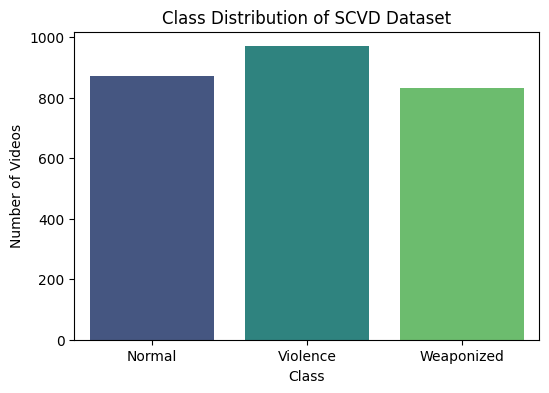

In [46]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label", palette="viridis")
plt.title("Class Distribution of SCVD Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Videos")
plt.show()


In [ ]:
from IPython.display import Video, display

def show_sample_videos(df, samples_per_class=1):
    for cls in CLASSES:
        print(f"\n### {cls} samples")
        subset = df[df["label"] == cls].sample(samples_per_class, random_state=42)

        for _, row in subset.iterrows():
            display(
                Video(
                    row["path"],
                    embed=True,
                    width=400,
                    
                )
            )

In [63]:
show_sample_videos(df, samples_per_class=2)



### Normal samples



### Violence samples



### Weaponized samples


In [49]:
def get_video_stats(path):
    cap = cv2.VideoCapture(path)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return frames, fps


In [50]:
df["frames"], df["fps"] = zip(*df["path"].apply(get_video_stats))
df["duration_sec"] = df["frames"] / df["fps"]
df.head()


,path,label,frames,fps,duration_sec
0,/kaggle/input/smartcity-cctv-violence-detectio...,Normal,30,30.0,1.0
1,/kaggle/input/smartcity-cctv-violence-detectio...,Normal,30,30.0,1.0
2,/kaggle/input/smartcity-cctv-violence-detectio...,Normal,30,30.0,1.0
3,/kaggle/input/smartcity-cctv-violence-detectio...,Normal,30,30.0,1.0
4,/kaggle/input/smartcity-cctv-violence-detectio...,Normal,30,30.0,1.0


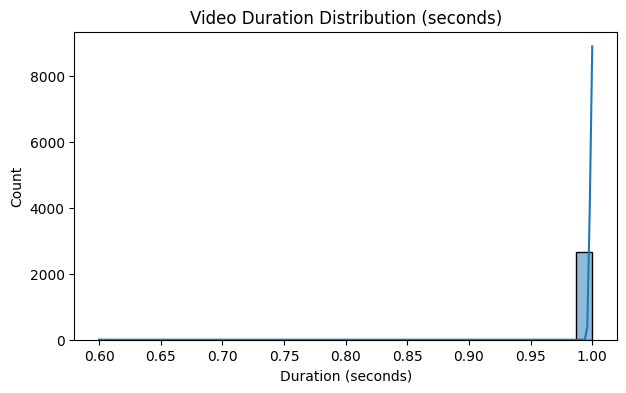

In [51]:
plt.figure(figsize=(7,4))
sns.histplot(df["duration_sec"], bins=30, kde=True)
plt.title("Video Duration Distribution (seconds)")
plt.xlabel("Duration (seconds)")
plt.show()


In [52]:
def get_resolution(path):
    cap = cv2.VideoCapture(path)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return w, h


In [53]:
df["width"], df["height"] = zip(*df["path"].apply(get_resolution))


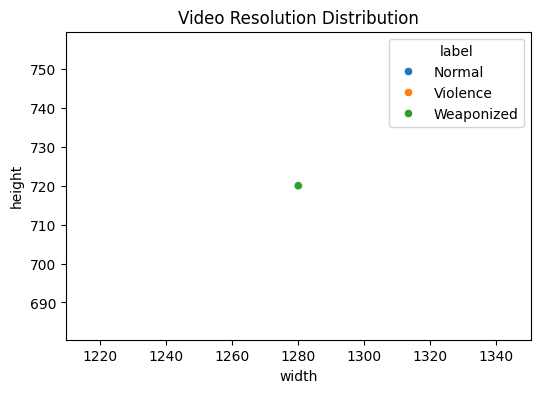

In [54]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["width"], y=df["height"], hue=df["label"])
plt.title("Video Resolution Distribution")
plt.show()


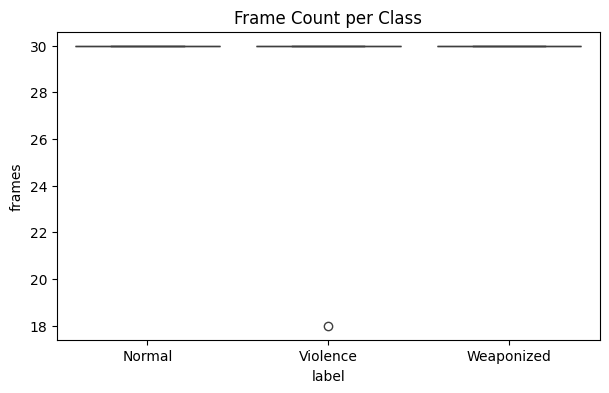

In [55]:
plt.figure(figsize=(7,4))
sns.boxplot(x="label", y="frames", data=df)
plt.title("Frame Count per Class")
plt.show()


In [56]:
def show_video_frames(video_path, num_frames=5):
    cap = cv2.VideoCapture(video_path)
    frames = []

    for _ in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            break
        frame = frame[:, :, ::-1]
        frames.append(frame)

    cap.release()

    plt.figure(figsize=(12,3))
    for i, f in enumerate(frames):
        plt.subplot(1, num_frames, i+1)
        plt.imshow(f)
        plt.axis("off")
    plt.show()


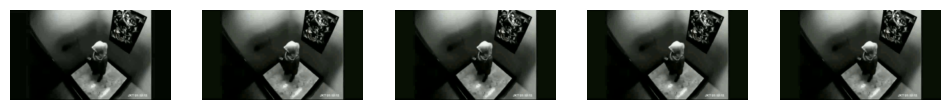

In [57]:
sample_video = df.iloc[0]["path"]
show_video_frames(sample_video)


In [17]:
def crop_center_square(frame):
    h, w = frame.shape[:2]
    m = min(h, w)
    return frame[(h-m)//2:(h+m)//2, (w-m)//2:(w+m)//2]


In [18]:
def load_video(path):
    cap = cv2.VideoCapture(path)
    frames = []

    while len(frames) < MAX_SEQ_LENGTH:
        ret, frame = cap.read()
        if not ret:
            break
        frame = crop_center_square(frame)
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = frame[:, :, ::-1]
        frames.append(frame)

    cap.release()
    return np.array(frames)


In [19]:
NUM_FEATURES = 1280

def build_mobilenet():
    base = keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    preprocess = keras.applications.mobilenet_v2.preprocess_input
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = preprocess(inp)
    out = base(x)
    return keras.Model(inp, out)



In [20]:
def build_efficientnet():
    base = keras.applications.EfficientNetB0(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    preprocess = keras.applications.efficientnet.preprocess_input
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = preprocess(inp)
    out = base(x)
    return keras.Model(inp, out)


In [21]:
def prepare_dataset(df, feature_extractor):
    n = len(df)
    X = np.zeros((n, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32")
    M = np.zeros((n, MAX_SEQ_LENGTH), dtype="bool")
    y = df["label"].map(LABEL_MAPPING).values

    for i, path in enumerate(df["path"].values):
        frames = load_video(path)
        l = len(frames)
        if l > 0:
            feats = feature_extractor.predict(frames, verbose=0)
            X[i, :l] = feats
            M[i, :l] = 1

    return (X, M), y



In [22]:
def build_classifier():
    f_in = keras.Input((MAX_SEQ_LENGTH, NUM_FEATURES))
    m_in = keras.Input((MAX_SEQ_LENGTH,), dtype="bool")

    x = keras.layers.Bidirectional(
        keras.layers.LSTM(256)
    )(f_in, mask=m_in)

    x = keras.layers.Dense(128, activation="relu")(x)
    x = keras.layers.Dropout(0.5)(x)

    out = keras.layers.Dense(len(CLASSES), activation="softmax")(x)

    model = keras.Model([f_in, m_in], out)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [24]:
mobilenet_extractor = build_mobilenet()

X_train, y_train = prepare_dataset(train_df, mobilenet_extractor)
X_test, y_test = prepare_dataset(test_df, mobilenet_extractor)

mobilenet_model = build_classifier()

mobilenet_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4728 - loss: 1.0575 - val_accuracy: 0.7351 - val_loss: 0.6743
Epoch 2/3
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7762 - loss: 0.5779 - val_accuracy: 0.7948 - val_loss: 0.4769
Epoch 3/3
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8431 - loss: 0.3857 - val_accuracy: 0.8470 - val_loss: 0.3569


In [25]:
y_pred = np.argmax(mobilenet_model.predict(X_test), axis=1)

print("MobileNetV2 Classification Report")
print(classification_report(y_test, y_pred, target_names=CLASSES))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
MobileNetV2 Classification Report
              precision    recall  f1-score   support

      Normal       0.96      0.83      0.89        88
    Violence       0.84      0.84      0.84        97
  Weaponized       0.77      0.88      0.82        83

    accuracy                           0.85       268
   macro avg       0.85      0.85      0.85       268
weighted avg       0.86      0.85      0.85       268



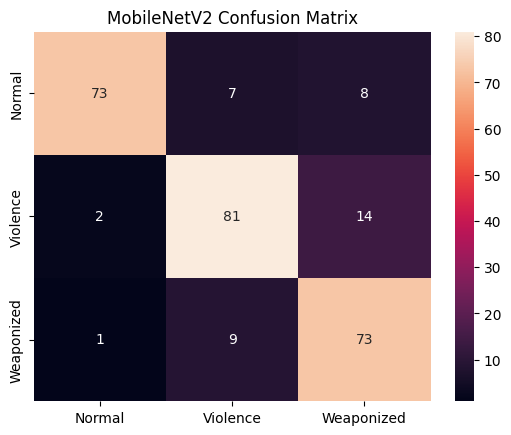

In [26]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("MobileNetV2 Confusion Matrix")
plt.show()


In [27]:
efficientnet_extractor = build_efficientnet()

X_train, y_train = prepare_dataset(train_df, efficientnet_extractor)
X_test, y_test = prepare_dataset(test_df, efficientnet_extractor)

efficientnet_model = build_classifier()

efficientnet_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch 1/3
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6486 - loss: 0.8210 - val_accuracy: 0.8433 - val_loss: 0.3926
Epoch 2/3
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9202 - loss: 0.2215 - val_accuracy: 0.8843 - val_loss: 0.3140
Epoch 3/3
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9441 - loss: 0.1585 - val_accuracy: 0.9366 - val_loss: 0.2138


In [28]:
y_pred = np.argmax(efficientnet_model.predict(X_test), axis=1)

print("EfficientNetB0 Classification Report")
print(classification_report(y_test, y_pred, target_names=CLASSES))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
EfficientNetB0 Classification Report
              precision    recall  f1-score   support

      Normal       0.91      0.94      0.93        88
    Violence       0.93      0.98      0.95        97
  Weaponized       0.97      0.88      0.92        83

    accuracy                           0.94       268
   macro avg       0.94      0.93      0.94       268
weighted avg       0.94      0.94      0.94       268



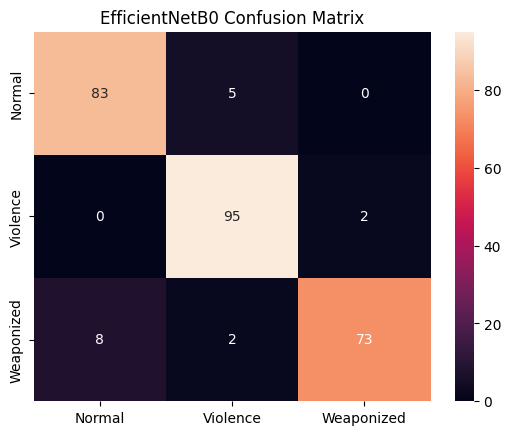

In [29]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()


In [ ]:
# Save models
mobilenet_model.save("mobilenet_violence_model.h5")
efficientnet_model.save("efficientnet_violence_model.h5")

print("Models saved successfully!")


Models saved successfully!


In [31]:
from tensorflow.keras.models import load_model

mobilenet_model = load_model("mobilenet_violence_model.h5")
efficientnet_model = load_model("efficientnet_violence_model.h5")

print("Models loaded successfully!")


Models loaded successfully!


In [32]:
mobilenet_extractor = build_mobilenet()


In [33]:
efficientnet_extractor = build_efficientnet()


In [34]:
def predict_video(video_path, model, feature_extractor):
    frames = load_video(video_path)

    if len(frames) == 0:
        return "No frames", 0.0

    # Extract features
    features = feature_extractor.predict(frames, verbose=0)

    # Pad sequence
    X = np.zeros((1, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32")
    M = np.zeros((1, MAX_SEQ_LENGTH), dtype="bool")

    length = len(features)
    X[0, :length] = features
    M[0, :length] = 1

    # Predict
    probs = model.predict([X, M], verbose=0)[0]
    pred_class = CLASSES[np.argmax(probs)]
    confidence = np.max(probs)

    return pred_class, confidence


In [35]:
test_video = "/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split/Test/Normal/Normal-Test001.avi"

label, conf = predict_video(
    test_video,
    mobilenet_model,
    mobilenet_extractor
)

print(f"Prediction (MobileNet): {label} ({conf:.2f})")


Prediction (MobileNet): Normal (0.97)


In [36]:
label, conf = predict_video(
    test_video,
    efficientnet_model,
    efficientnet_extractor
)

print(f"Prediction (EfficientNet): {label} ({conf:.2f})")


Prediction (EfficientNet): Normal (1.00)


In [37]:
test_video = "/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split/Test/Violence/Violence-Test002.avi"

label, conf = predict_video(
    test_video,
    mobilenet_model,
    mobilenet_extractor
)

print(f"Prediction (MobileNet): {label} ({conf:.2f})")

Prediction (MobileNet): Violence (0.71)


In [38]:
label, conf = predict_video(
    test_video,
    efficientnet_model,
    efficientnet_extractor
)

print(f"Prediction (EfficientNet): {label} ({conf:.2f})")

Prediction (EfficientNet): Violence (0.96)


In [41]:
test_video = "/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split/Test/Weaponized/Weaponized-Test009.avi"

label, conf = predict_video(
    test_video,
    mobilenet_model,
    mobilenet_extractor
)

print(f"Prediction (MobileNet): {label} ({conf:.2f})")

Prediction (MobileNet): Weaponized (0.99)


In [42]:
label, conf = predict_video(
    test_video,
    efficientnet_model,
    efficientnet_extractor
)

print(f"Prediction (EfficientNet): {label} ({conf:.2f})")

Prediction (EfficientNet): Weaponized (1.00)


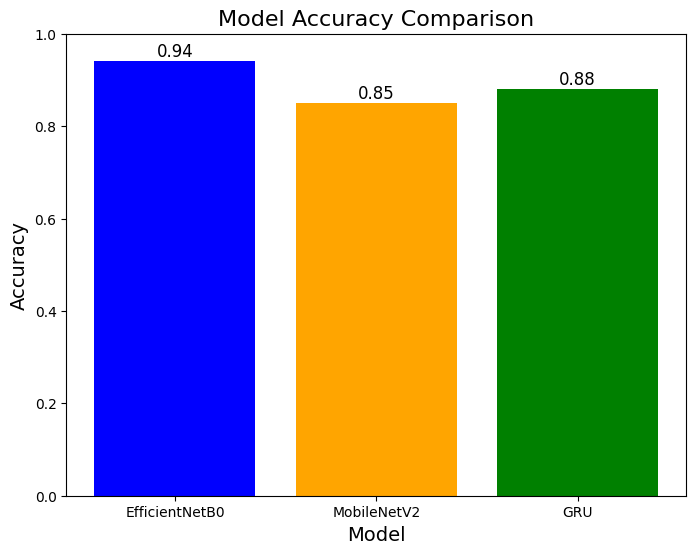

In [1]:
import matplotlib.pyplot as plt

# Model names and corresponding accuracies
models = ['EfficientNetB0', 'MobileNetV2', 'GRU']
accuracies = [0.94, 0.85, 0.88]

# Create the plot
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['blue', 'orange', 'green'])

# Adding labels and title
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, 1)  # Set y-axis limit to 1 for percentage representation

# Display the accuracy on top of each bar
for i in range(len(accuracies)):
    plt.text(i, accuracies[i] + 0.01, f'{accuracies[i]:.2f}', ha='center', fontsize=12)

# Show the plot
plt.show()
